In [1]:
# Import libraries
import pickle
import numpy as np
import anndata as ad
import pandas as pd
import scanpy as sc
import scipy
import scipy.sparse as sp 
import matplotlib.pyplot as plt
import anndata
from anndata import AnnData

# For plotting
import seaborn as sns

# For PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# For umap
import umap

# SCVI
import scvi
import cellxgene_census
import cellxgene_census.experimental

# For ML training
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
from scipy.sparse import issparse, vstack

# For NNLS
from scipy.optimize import nnls

/nfs/sw/easybuild/software/custom-conda/geneformer-1.0/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/nfs/home/aoku/.local/lib/python3.10/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
import warnings

# Suppress specific types of warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
# For geneformer
from geneformer import EmbExtractor
from geneformer import TranscriptomeTokenizer

### Get Single Cell Data

In [4]:
# Load path (path contains seurat object with our annotations)
czi_path = "/gpfs/commons/groups/compbio/projects/CZI_endom/RNA_temp/62_harmony_102224_Seuratv34_newannot_counts.h5ad"

# Read the h5ad file
adata = sc.read_h5ad(czi_path)

print(adata)

AnnData object with n_obs × n_vars = 171459 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'peak_region_fragments', 'pct_reads_in_peaks', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'blacklist_fraction', 'nCount_GA', 'nFeature_GA', 'Percent_mito', 'S.Score', 'G2M.Score', 'Phase', 'qc', 'atac_qc', 'sample', 'RNA_snn_res.0.1', 'seurat_clusters', 'RNA_snn_res.0.2', 'RNA_snn_res.0.5', 'RNA_snn_res.0.8', 'RNA.weight', 'ATAC.weight', 'nCount_HTO', 'nFeature_HTO', 'doubletdetection', 'RNA_type', 'freemuxlet_doublet', 'freemuxlet_genotype', 'libnorm_demux', 'genotype_call', 'hto_call', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'DoubletScore', 'DoubletEnrichment', 'BlacklistRatio', 'AMULET.p.value', 'AMULET.q.value', 'AMULET.final', 'ATAC_PASS', 'id', 'RNA_snn_res.0.4', 'menopaus

In [5]:
adata.obs["newlineage"].value_counts()

newlineage
Endothelial           54188
Epithelial            53709
Mesenchymal           47684
Epithelial+Stromal     9876
Lymphocytes            3298
Myeloid                1883
Stem                    821
Name: count, dtype: int64

In [6]:
adata.obs["newtype"].value_counts()

newtype
EpithelialGL_harmonal    36381
Endothelial              35718
Stromal_EMT              19847
Smooth_mucle             15147
Endothelial_vasc         10587
EpithelialPino           10425
EpStrMix                  9876
Endothelial_lymp          7883
Stromal_noEMT             6058
Epithelial_MUC1           4946
eMSCs_peri                4133
Lymphoid                  3298
DSCs                      2499
Epithelial_ciliated       1957
Myeloid                   1883
StemPro                    821
Name: count, dtype: int64

In [7]:
# Get counts data (scVi requires count info)
adata.layers["counts"] = adata.raw.X.copy()
adata.layers["logcounts"] = adata.X.copy()

In [8]:
# Add HECA annotations to adata (annotation from published HECA dataset)
heca_annot = pd.read_csv("/nfs/home/rfu/projects/CZI_endom/CZI_HECAtype.csv.gz")

# Check if cell index matches
print(pd.Series(adata.obs_names == heca_annot.cell).value_counts())

# Add to anndata
adata.obs["heca_celltype"] = heca_annot["celltype"].values
adata.obs["heca_lineage"] = heca_annot["lineage"].values

True    171459
Name: count, dtype: int64


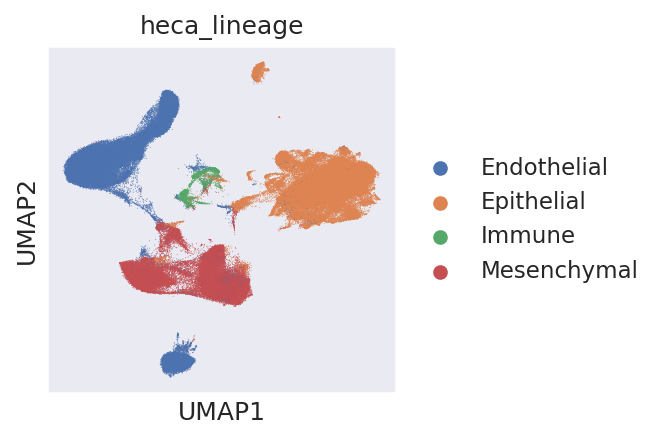

In [9]:
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": (150)}):
    sc.pl.umap(adata, color='heca_lineage')

In [10]:
# Prep data for scVI
# Get ensembl IDs - map gene symbol to ensembl ID
gene_ids = pd.read_csv("/gpfs/commons/groups/compbio/projects/CZI_endom/RNA_temp/gene_names_gene_ids_czi_endo.csv", index_col= False)

gene_id_dict = pd.DataFrame({
    'gene_symbol': gene_ids["gene_name"],
    'ensembl_id': gene_ids["gene_id"]})

gene_id_dict = gene_id_dict.set_index('gene_symbol')['ensembl_id'].to_dict()

ensembl_ids = [gene_id_dict.get(gene, 'NA') for gene in adata.var_names]

# Add ensembl IDs to anndata object
adata.var["gene_names"] = adata.var_names
adata.var["ensembl_id"] = ensembl_ids
adata.var_names = ensembl_ids

# Remove duplicated IDs
adata = adata[:, ~adata.var["ensembl_id"].duplicated()]

In [11]:
# Check for duplicated IDs
adata.var["ensembl_id"].duplicated().any()

del adata.varm["HARMONY"]
del adata.varm["PCs"]

In [12]:
adata.obs["cell_index"]  = adata.obs.index #required for geneformer
adata.obs["cell_id"] = adata.obs["cell_index"] #required for geneformer

In [13]:
adata.obs['n_counts'] = np.array(adata.X.sum(axis=1)).flatten() #number of transcripts per cell

In [14]:
#### Split data into training and testing sets
# Get unique sample IDs
unique_ids = adata.obs['id'].unique()

# Split the sample IDs
train_ids, test_ids = train_test_split(unique_ids, test_size=0.15, random_state=42)

# Create boolean masks
train_mask = adata.obs['id'].isin(train_ids)
test_mask = adata.obs['id'].isin(test_ids)

# Subset the AnnData object
adata_train = adata[train_mask].copy()
adata_test = adata[test_mask].copy()

In [15]:
print(adata_train)

AnnData object with n_obs × n_vars = 149864 × 36592
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'peak_region_fragments', 'pct_reads_in_peaks', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'blacklist_fraction', 'nCount_GA', 'nFeature_GA', 'Percent_mito', 'S.Score', 'G2M.Score', 'Phase', 'qc', 'atac_qc', 'sample', 'RNA_snn_res.0.1', 'seurat_clusters', 'RNA_snn_res.0.2', 'RNA_snn_res.0.5', 'RNA_snn_res.0.8', 'RNA.weight', 'ATAC.weight', 'nCount_HTO', 'nFeature_HTO', 'doubletdetection', 'RNA_type', 'freemuxlet_doublet', 'freemuxlet_genotype', 'libnorm_demux', 'genotype_call', 'hto_call', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'DoubletScore', 'DoubletEnrichment', 'BlacklistRatio', 'AMULET.p.value', 'AMULET.q.value', 'AMULET.final', 'ATAC_PASS', 'id', 'RNA_snn_res.0.4', 'menopaus

In [16]:
#adata_test.obs["heca_lineage"].value_counts()
len(adata_test.obs["id"].unique())

10

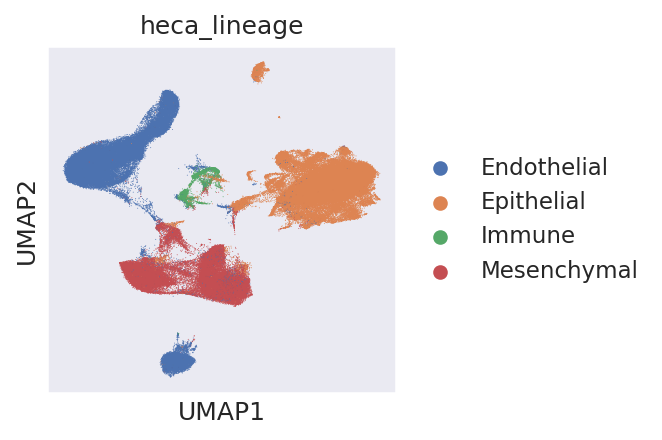

In [17]:
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": (150)}):
    sc.pl.umap(adata_train, color='heca_lineage')

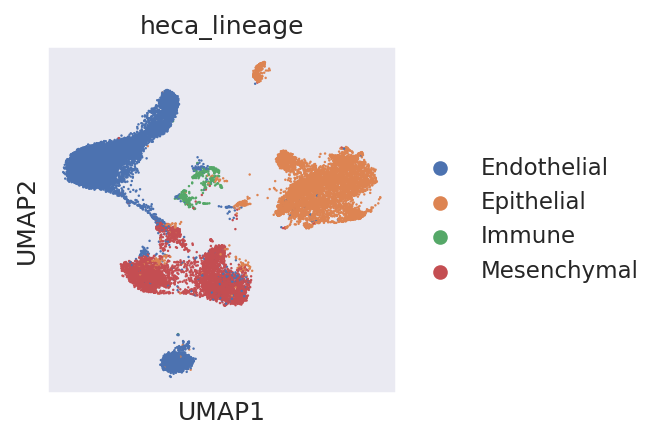

In [18]:
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": (150)}):
    sc.pl.umap(adata_test, color='heca_lineage')

### Get Signature Matrix Using Single Cell Dataset

In [19]:
def create_signature_matrix(adata, groupby="cell_type"):
    """
    Create a signature matrix (genes x cell types) from AnnData.
    The signature is the average expression per gene per cell type.
    
    Parameters
    ----------
    adata : AnnData
        Single-cell AnnData object (cells x genes).
    groupby : str
        Column in adata.obs defining cell types or groups.

    Returns
    -------
    pd.DataFrame
        Signature matrix (genes x cell types).
    """
    # Convert to DataFrame for convenience
    df = pd.DataFrame(adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X,
                      index=adata.obs_names,
                      columns=adata.var_names)

    # Add cell type annotations
    df[groupby] = adata.obs[groupby].values

    # Average expression per cell type
    signature = df.groupby(groupby).mean().T  # genes x cell types
    return signature

In [20]:
def create_signature_matrix_latent(adata, groupby="cell_type", latent_key="scVI"):
    """
    Create a signature matrix (latent dimensions x cell types) from AnnData.
    The signature is the average latent representation per cell type.
    
    Parameters
    ----------
    adata : AnnData
        Single-cell AnnData object.
    groupby : str
        Column in adata.obs defining cell types or groups.
    latent_key : str
        Key in adata.obsm where latent representations (e.g., scVI) are stored.

    Returns
    -------
    pd.DataFrame
        Signature matrix (latent dimensions x cell types).
    """
    if latent_key not in adata.obsm:
        raise ValueError(f"Latent key '{latent_key}' not found in adata.obsm")

    # Extract latent representation (cells x latent dims)
    latent = pd.DataFrame(
        adata.obsm[latent_key],
        index=adata.obs_names,
        #columns=[f"{latent_key}_{i}" for i in range(adata.obsm[latent_key].shape[1])]
    )

    # Add cell type annotation
    latent[groupby] = adata.obs[groupby].values

    # Average latent dimensions per cell type
    signature = latent.groupby(groupby).mean().T  # latent dims x cell types (try sum instead of mean)
    return signature

### Function to plot estimated vs true proportions

In [21]:
def plot_true_vs_predicted(y_test_df, predicted_proportions, n_cols=4, figsize_per_plot=(3, 3), dot_size=5):

    # Get column names (cell types or lineages)
    cols = predicted_proportions.columns
    n_rows = int(np.ceil(len(cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * figsize_per_plot[0], n_rows * figsize_per_plot[1]))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        x = y_test_df[col]
        y = predicted_proportions[col]

        # Scatterplot
        sns.scatterplot(x=x, y=y, alpha=0.7, ax=ax, s=dot_size)

        # Identity line
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--')

        # Correlation coefficient
        corr, _ = pearsonr(x, y)
        ax.text(
            0.05, 0.95, f"r = {corr:.2f}",
            transform=ax.transAxes,
            verticalalignment='top',
            fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.5)
        )

        # Titles and labels
        ax.set_title(f'{col}')
        ax.set_xlabel('True')
        ax.set_ylabel('Predicted')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


### Split data into train and test splits

In [22]:
# Limit signature matrix to just data used in training set
train_list = ['B2-CZI08N', 'B3-CZI11N', 'B3-CZI05N']
adata_train = adata[adata.obs["id"].isin(train_list)].copy()
adata_train.obs["batch"] = "train"

In [23]:
adata_train.obs["heca_lineage"].value_counts()

heca_lineage
Mesenchymal    4768
Epithelial     4339
Endothelial    3635
Immune          489
Name: count, dtype: int64

In [24]:
adata_train

AnnData object with n_obs × n_vars = 13231 × 36592
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'peak_region_fragments', 'pct_reads_in_peaks', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'blacklist_fraction', 'nCount_GA', 'nFeature_GA', 'Percent_mito', 'S.Score', 'G2M.Score', 'Phase', 'qc', 'atac_qc', 'sample', 'RNA_snn_res.0.1', 'seurat_clusters', 'RNA_snn_res.0.2', 'RNA_snn_res.0.5', 'RNA_snn_res.0.8', 'RNA.weight', 'ATAC.weight', 'nCount_HTO', 'nFeature_HTO', 'doubletdetection', 'RNA_type', 'freemuxlet_doublet', 'freemuxlet_genotype', 'libnorm_demux', 'genotype_call', 'hto_call', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'DoubletScore', 'DoubletEnrichment', 'BlacklistRatio', 'AMULET.p.value', 'AMULET.q.value', 'AMULET.final', 'ATAC_PASS', 'id', 'RNA_snn_res.0.4', 'menopausa

### Get latent embeddings on averaged gex by tissue type

In [25]:
# Limit signature matrix to just data used in training set
train_list = ['B2-CZI08N', 'B3-CZI11N', 'B3-CZI05N']
adata_train = adata[adata.obs["id"].isin(train_list)].copy()
adata_train.obs["batch"] = "train"

In [26]:
signature_matrix_gex_to_scvi = create_signature_matrix(adata_train, groupby = "heca_lineage")

In [27]:
signature_matrix_gex_to_scvi.head()

heca_lineage,Endothelial,Epithelial,Immune,Mesenchymal
ENSG00000243485,0.000000,0.000000,0.000000,0.000000
ENSG00000237613,0.000000,0.000000,0.000000,0.000000
ENSG00000186092,0.000000,0.000461,0.000000,0.000210
ENSG00000238009,0.003576,0.008758,0.002045,0.003146
ENSG00000239945,0.000275,0.000000,0.002045,0.000000


In [28]:
# convert bulk to anndata
X = signature_matrix_gex_to_scvi.T  # Now rows = samples, columns = genes

# Create AnnData object
adata_bulk = anndata.AnnData(X)

# Set sample names and gene names
adata_bulk.obs_names = X.index     
adata_bulk.var_names = X.columns 

# Add batch information
adata_bulk.obs["batch"] = "czi pseudobulk"
adata_bulk.obs["id"] = X.index 

In [140]:
# Define scVI path
scvi_path = "/gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01"

# Extract scVI embeddings with single forward pass
scvi.model.SCVI.prepare_query_anndata(adata_bulk, 
                                      scvi_path)

vae_q = scvi.model.SCVI.load_query_data(
    adata_bulk,
    scvi_path,
)

# # This allows for a simple forward pass
vae_q.is_trained = True
signature_matrix_scvi_bulk = vae_q.get_latent_representation()
signature_matrix_scvi_bulk = pd.DataFrame(signature_matrix_scvi_bulk)
signature_matrix_scvi_bulk.index = adata_bulk.obs["id"]

INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  
INFO     Found 63.5375% reference vars in query data.                                                              
INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  


In [141]:
signature_matrix_scvi_bulk.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
id,,,,,,,,,,,,,,,,,,,,,
Endothelial,0.001497,0.001125,-1.577730,0.004290,-0.001223,-0.002060,0.098821,0.000343,0.006172,-0.005204,...,0.009338,-0.000968,-0.007512,1.890655,0.005627,0.000361,1.522538,-0.000333,-0.001929,0.000775
Epithelial,0.000255,0.000766,0.232139,0.004026,-0.000459,-0.006598,0.441168,-0.003653,0.006093,-0.007870,...,0.004638,-0.006993,-0.010010,2.254633,0.001860,0.005168,0.146118,0.005308,0.002492,0.002072
Immune,-0.000333,0.003231,0.266962,0.001708,-0.001966,-0.008228,-0.089375,-0.004623,0.010474,-0.007385,...,0.004950,-0.006364,-0.005922,2.510226,0.003317,0.004240,0.209063,0.001191,0.001041,-0.004083
Mesenchymal,0.001452,0.004273,-0.093137,0.002219,-0.001983,-0.001824,-0.076658,-0.000626,0.002972,-0.000250,...,0.002976,0.000129,0.003326,0.644909,-0.001470,-0.004827,1.887706,-0.002369,-0.001269,-0.002988


In [142]:
signature_matrix_scvi_bulk.to_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/scVI_signature_matrix_from_pseudobulk.csv")

### Convert signature matrix to scVI embeddings

In [276]:
# Define scVI path
scvi_path = "/gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01"

# Extract scVI embeddings with single forward pass
scvi.model.SCVI.prepare_query_anndata(adata_train, 
                                      scvi_path)

vae_q = scvi.model.SCVI.load_query_data(
    adata_train,
    scvi_path,
)

# # This allows for a simple forward pass
vae_q.is_trained = True
latent_czi_train = vae_q.get_latent_representation()

INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  
INFO     Found 63.5375% reference vars in query data.                                                              
INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  


In [277]:
adata_train

AnnData object with n_obs × n_vars = 13231 × 8000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'peak_region_fragments', 'pct_reads_in_peaks', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'blacklist_fraction', 'nCount_GA', 'nFeature_GA', 'Percent_mito', 'S.Score', 'G2M.Score', 'Phase', 'qc', 'atac_qc', 'sample', 'RNA_snn_res.0.1', 'seurat_clusters', 'RNA_snn_res.0.2', 'RNA_snn_res.0.5', 'RNA_snn_res.0.8', 'RNA.weight', 'ATAC.weight', 'nCount_HTO', 'nFeature_HTO', 'doubletdetection', 'RNA_type', 'freemuxlet_doublet', 'freemuxlet_genotype', 'libnorm_demux', 'genotype_call', 'hto_call', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'DoubletScore', 'DoubletEnrichment', 'BlacklistRatio', 'AMULET.p.value', 'AMULET.q.value', 'AMULET.final', 'ATAC_PASS', 'id', 'RNA_snn_res.0.4', 'menopausal

In [159]:
# Add latent dimensions 
adata_train.obsm["scVI"]= latent_czi_train

In [164]:
signature_matrix = create_signature_matrix_latent(adata_train, groupby = "heca_lineage", latent_key= "scVI")

In [165]:
signature_matrix.head()

heca_lineage,Endothelial,Epithelial,Immune,Mesenchymal
0,0.002324,0.000316,0.001325,0.001148
1,-0.001796,-0.002843,-0.000540,0.001511
2,-1.770241,0.310567,0.230386,-0.243586
3,0.002996,0.003356,0.002470,0.003677
4,0.001282,0.001384,0.001206,0.000423


In [123]:
#signature_matrix.to_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/scVI_signature_matrix.csv")

### Convert signature matrix to geneformer embeddings

In [29]:
# Limit signature matrix to just data used in training set
train_list = ['B2-CZI08N', 'B3-CZI11N', 'B3-CZI05N']
adata_train = adata[adata.obs["id"].isin(train_list)].copy()
adata_train.obs["batch"] = "train"

In [30]:
print(adata_train)

AnnData object with n_obs × n_vars = 13231 × 36592
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'peak_region_fragments', 'pct_reads_in_peaks', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'blacklist_fraction', 'nCount_GA', 'nFeature_GA', 'Percent_mito', 'S.Score', 'G2M.Score', 'Phase', 'qc', 'atac_qc', 'sample', 'RNA_snn_res.0.1', 'seurat_clusters', 'RNA_snn_res.0.2', 'RNA_snn_res.0.5', 'RNA_snn_res.0.8', 'RNA.weight', 'ATAC.weight', 'nCount_HTO', 'nFeature_HTO', 'doubletdetection', 'RNA_type', 'freemuxlet_doublet', 'freemuxlet_genotype', 'libnorm_demux', 'genotype_call', 'hto_call', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'DoubletScore', 'DoubletEnrichment', 'BlacklistRatio', 'AMULET.p.value', 'AMULET.q.value', 'AMULET.final', 'ATAC_PASS', 'id', 'RNA_snn_res.0.4', 'menopausa

In [27]:
adata_train.write_h5ad("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/signature_mat/train_set.h5ad")

In [28]:
from geneformer import TranscriptomeTokenizer

# Initialize tokenizer
tk = TranscriptomeTokenizer({"heca_lineage": "heca_lineage"}, 
                            model_input_size=4096, special_token=True,
                            chunk_size = 512,
                            gene_median_file = "/gpfs/commons/groups/compbio/projects/rf_projects/rf_models/geneformer_pkl/gene_median_dictionary_gc95M.pkl",
                            token_dictionary_file = "/gpfs/commons/groups/compbio/projects/rf_projects/rf_models/geneformer_pkl/token_dictionary_gc95M.pkl",
                            gene_mapping_file = "/gpfs/commons/groups/compbio/projects/rf_projects/rf_models/geneformer_pkl/ensembl_mapping_dict_gc95M.pkl")

# Tokenize data
tk.tokenize_data("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/signature_mat/", 
                 "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/signature_mat/tokenize/", 
                 "token_train_set", 
                 file_format="h5ad")

Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/signature_mat/train_set.h5ad


100%|██████████| 26/26 [00:36<00:00,  1.39s/it]


/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/signature_mat/train_set.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.


In [42]:
from geneformer import perturber_utils as pu

model = pu.load_model(model_type="Pretrained", 
                      num_classes=0, 
                      model_directory="/gpfs/commons/groups/compbio/projects/CZI_endom/geneformer/output/czi_endo/250501_geneformer_cellClassifier_cell_annot_subset/ksplit1/",
                      mode="eval")

import pickle
with open("/gpfs/commons/groups/compbio/projects/rf_condas/geneformer/lib/python3.10/site-packages/geneformer/token_dictionary_gc95M.pkl", "rb") as f:
    gene_token_dict = pickle.load(f)
token_gene_dict = {v: k for k, v in gene_token_dict.items()}
pad_token_id = gene_token_dict.get("<pad>")
# load input
filtered_input_data = pu.load_and_filter(filter_data=None, nproc=1, 
                                         input_data_file="/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/signature_mat/tokenize/token_train_set.dataset/")

Some weights of BertForMaskedLM were not initialized from the model checkpoint at /gpfs/commons/groups/compbio/projects/CZI_endom/geneformer/output/czi_endo/250501_geneformer_cellClassifier_cell_annot_subset/ksplit1/ and are newly initialized: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [47]:
from geneformer import get_embs

state_embs_dict = get_embs(model,
                           filtered_input_data,
                           emb_mode="cell",
                           layer_to_quant=0,
                           pad_token_id=pad_token_id,
                           token_gene_dict=token_gene_dict,
                           special_token=True,
                           forward_batch_size=50)

CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.
100%|██████████| 1/1 [00:00<00:00,  7.50it/s]


In [42]:
tempout = pd.DataFrame.from_dict(state_embs_dict.cpu().numpy())
df = filtered_input_data.to_pandas()
tempout.index = df['heca_lineage'] + '_' + df.index.astype(str)
tempout["heca_lineage"] = df['heca_lineage'].values
#tempout.index = data3.obs.index
tempout.to_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/geneformer_finetuned_signature_matrix.csv")

In [63]:
len(set(adata_train.var["ensembl_id"]))

5084

### Average out genes before running geneformer

In [34]:
# Limit signature matrix to just data used in training set
train_list = ['B2-CZI08N', 'B3-CZI11N', 'B3-CZI05N']
adata_train = adata[adata.obs["id"].isin(train_list)].copy()
adata_train.obs["batch"] = "train"

In [35]:
gex_ave_by_lineage = create_signature_matrix(adata_train, groupby = "heca_lineage")

In [36]:
gex_ave_by_lineage = gex_ave_by_lineage.T

In [37]:
# Create anndata
data2 = gex_ave_by_lineage
data3 = sc.AnnData(data2)
data3.obs['cell_type'] = "unknown"
data3.obs['n_counts'] = np.sum(data3.X, axis = 1).tolist()
data3.var["ensembl_id"] = data3.var_names
data3.X = scipy.sparse.csc_matrix(data3.X)
data3.write_h5ad("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/signature_mat_frm_pseudobulk/train_set.h5ad")

In [121]:
from geneformer import TranscriptomeTokenizer

# Initialize tokenizer
tk = TranscriptomeTokenizer({"cell_type": "cell_type"}, 
                            model_input_size=4096, special_token=True,
                            chunk_size = 512,
                            gene_median_file = "/gpfs/commons/groups/compbio/projects/rf_projects/rf_models/geneformer_pkl/gene_median_dictionary_gc95M.pkl",
                            token_dictionary_file = "/gpfs/commons/groups/compbio/projects/rf_projects/rf_models/geneformer_pkl/token_dictionary_gc95M.pkl",
                            gene_mapping_file = "/gpfs/commons/groups/compbio/projects/rf_projects/rf_models/geneformer_pkl/ensembl_mapping_dict_gc95M.pkl")

# Tokenize data
tk.tokenize_data("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/signature_mat_frm_pseudobulk/", 
                 "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/signature_mat_frm_pseudobulk/tokenize/", 
                 "token_train_set", 
                 file_format="h5ad")

Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/signature_mat_frm_pseudobulk/train_set.h5ad


100%|██████████| 1/1 [00:00<00:00,  7.45it/s]


/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/signature_mat_frm_pseudobulk/train_set.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.


In [48]:
from geneformer import perturber_utils as pu

model = pu.load_model(model_type="Pretrained", 
                      num_classes=0, 
                      model_directory="/gpfs/commons/groups/compbio/projects/CZI_endom/geneformer/output/czi_endo/250501_geneformer_cellClassifier_cell_annot_subset/ksplit1/",
                      mode="eval")

import pickle
with open("/gpfs/commons/groups/compbio/projects/rf_condas/geneformer/lib/python3.10/site-packages/geneformer/token_dictionary_gc95M.pkl", "rb") as f:
    gene_token_dict = pickle.load(f)
token_gene_dict = {v: k for k, v in gene_token_dict.items()}
pad_token_id = gene_token_dict.get("<pad>")
# load input
filtered_input_data = pu.load_and_filter(filter_data=None, nproc=1, 
                                         input_data_file="/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/signature_mat_frm_pseudobulk/tokenize/token_train_set.dataset/")

Some weights of BertForMaskedLM were not initialized from the model checkpoint at /gpfs/commons/groups/compbio/projects/CZI_endom/geneformer/output/czi_endo/250501_geneformer_cellClassifier_cell_annot_subset/ksplit1/ and are newly initialized: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [49]:
from geneformer import get_embs

state_embs_dict = get_embs(model,
                           filtered_input_data,
                           emb_mode="cell",
                           layer_to_quant=0,
                           pad_token_id=pad_token_id,
                           token_gene_dict=token_gene_dict,
                           special_token=True,
                           forward_batch_size=50)

CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.
100%|██████████| 1/1 [00:00<00:00,  7.25it/s]


In [50]:
tempout = pd.DataFrame.from_dict(state_embs_dict.cpu().numpy())
df = filtered_input_data.to_pandas()
tempout.index = df['cell_type'] + '_' + df.index.astype(str)
tempout.index = data3.obs.index
tempout.to_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/geneformer_finetuned_signature_matrix_from_pseudobulk.csv")

# Test out NNLS

In [52]:
# Function to get NNLS
def estimate_proportions(bulk_df, signature_matrix):
    """
    Estimate cell type proportions in bulk samples via NNLS.
    
    Parameters
    ----------
    bulk_df : pd.DataFrame
        Bulk expression (genes x samples).
    signature_matrix : pd.DataFrame
        Signature matrix (genes x cell types).
    
    Returns
    -------
    pd.DataFrame
        Proportions (samples x cell types).
    """
    # Keep only common genes
    common_genes = bulk_df.index.intersection(signature_matrix.index)
    bulk = bulk_df.loc[common_genes]
    sig = signature_matrix.loc[common_genes]

    props = []
    for sample in bulk.columns:
        y = bulk[sample].values
        x = sig.values
        coeffs, _ = nnls(x, y)  # non-negative least squares
        coeffs = coeffs / coeffs.sum()  # normalize to proportions
        props.append(coeffs)

    props_df = pd.DataFrame(props, index=bulk.columns, columns=sig.columns)
    return props_df

### Read GEX Data used for creating pseudobulk

In [3]:
# Read in pseudbulks transform using PCA
import pandas as pd
train_pseudobulk_czi = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/pseudobulk_train_set.csv", index_col=0)
test_pseudobulk_czi = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/pseudobulk_test_set.csv")

In [73]:
sig_matrix_gex = create_signature_matrix(adata_train, groupby="heca_lineage")

### NNLS with GEX

In [74]:
# Transpose pseudobulk to match signature matrix 
test_pseudobulk_czi_T = test_pseudobulk_czi.copy().T

In [75]:
nnls_gex = estimate_proportions(bulk_df = test_pseudobulk_czi_T, signature_matrix = sig_matrix_gex)

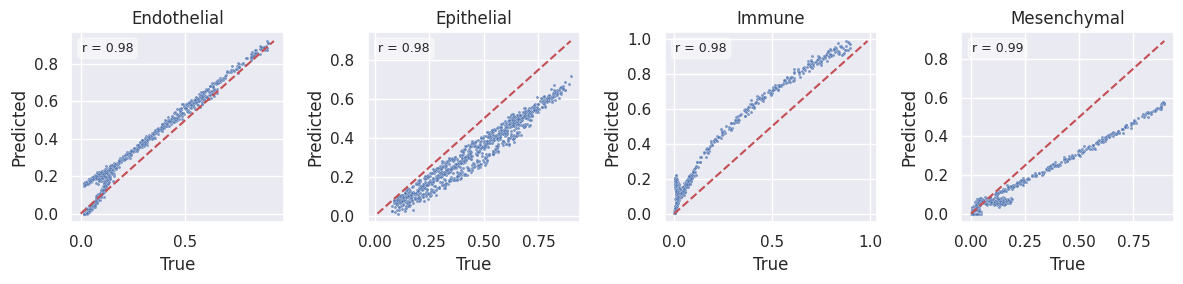

In [76]:
plot_true_vs_predicted(y_test_df=test_czi_cell_prop, predicted_proportions=nnls_gex)

In [77]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Mean Absolute Error
mae = mean_absolute_error(test_czi_cell_prop[nnls_gex.columns], nnls_gex)

# Mean Squared Error
mse = mean_squared_error(test_czi_cell_prop[nnls_gex.columns], nnls_gex)

# Root Mean Squared Error
rmse = np.sqrt(mse)

print(f"MAE : {mae:.3f}")
print(f"MSE : {mse:.3f}")
print(f"RMSE: {rmse:.3f}")

MAE : 0.092
MSE : 0.013
RMSE: 0.114


In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Store results per column
results = []
for col in nnls_gex.columns:
    y_true = test_czi_cell_prop[col]
    y_pred = nnls_gex[col]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    results.append({"Cell_Type": col, "MAE": mae, "MSE": mse, "RMSE": rmse})

# Convert to DataFrame for easy plotting
results_df = pd.DataFrame(results)
print(results_df)

     Cell_Type       MAE       MSE      RMSE
0  Endothelial  0.067109  0.006142  0.078374
1   Epithelial  0.125675  0.019386  0.139235
2       Immune  0.113480  0.016209  0.127316
3  Mesenchymal  0.062027  0.010156  0.100776


### NNLS with scVI

In [229]:
# Get scVI embeddings
sig_matrix_scvi = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/scVI_signature_matrix.csv", index_col=0)

# add "scVI" to index names
sig_matrix_scvi.index = ["scVI_" + str(i) for i in sig_matrix_scvi.index]

In [145]:
# Transpose pseudobulk to match signature matrix 
scvi_latent_czi_pseudobulk_test_T = scvi_latent_czi_pseudobulk_test.copy().T

# add "scVI" to index names
scvi_latent_czi_pseudobulk_test_T.index = ["scVI_" + str(i) for i in scvi_latent_czi_pseudobulk_test_T.index]

In [231]:
nnls_scvi = estimate_proportions(bulk_df = scvi_latent_czi_pseudobulk_test_T, signature_matrix = sig_matrix_scvi)

In [232]:
nnls_scvi_2 = nnls_deconvolution(signature_matrix=sig_matrix_scvi, bulk_data=scvi_latent_czi_pseudobulk_test_T)

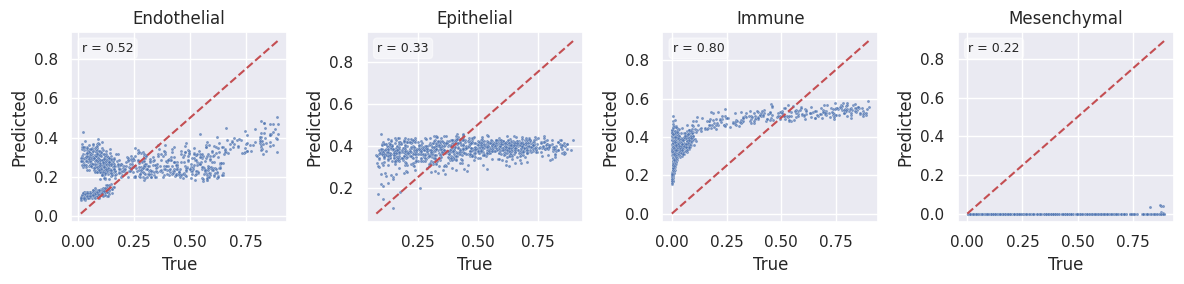

In [233]:
plot_true_vs_predicted(y_test_df=test_czi_cell_prop, predicted_proportions=nnls_scvi)

In [234]:
sig_matrix_scvi.columns

Index(['Endothelial', 'Epithelial', 'Immune', 'Mesenchymal'], dtype='object')

### NNLS with scVI Pseudobulk

In [143]:
sig_matrix_scvi_from_pseudobulk = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/scVI_signature_matrix_from_pseudobulk.csv", index_col=0)
sig_matrix_scvi_from_pseudobulk = sig_matrix_scvi_from_pseudobulk.T
sig_matrix_scvi_from_pseudobulk.index = ["scVI_" + str(i) for i in sig_matrix_scvi_from_pseudobulk.index]

In [146]:
nnls_scvi_from_pseudobulk = estimate_proportions(bulk_df = scvi_latent_czi_pseudobulk_test_T, signature_matrix = sig_matrix_scvi_from_pseudobulk)

/tmp/ipykernel_3948472/3673166973.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(x, y)


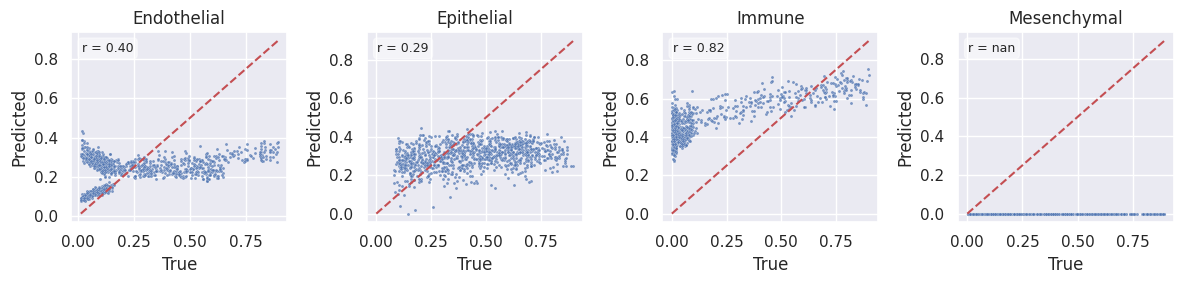

In [147]:
plot_true_vs_predicted(y_test_df=test_czi_cell_prop, predicted_proportions=nnls_scvi_from_pseudobulk)

### MuSiC

In [26]:
# Read music results
music_deconv = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/outputs/music_prop_pseudobulk_czi_vs_czi_single_cell_ref_estimated_heca_lineage.csv",
                          index_col=0)
music_deconv.reset_index(drop=True, inplace=True)

In [27]:
music_deconv = music_deconv[["Endothelial", "Immune", "Mesenchymal", "Epithelial"]]
#music_deconv.reset_index(drop=True, inplace=True)

In [28]:
music_deconv.columns

Index(['Endothelial', 'Immune', 'Mesenchymal', 'Epithelial'], dtype='object')

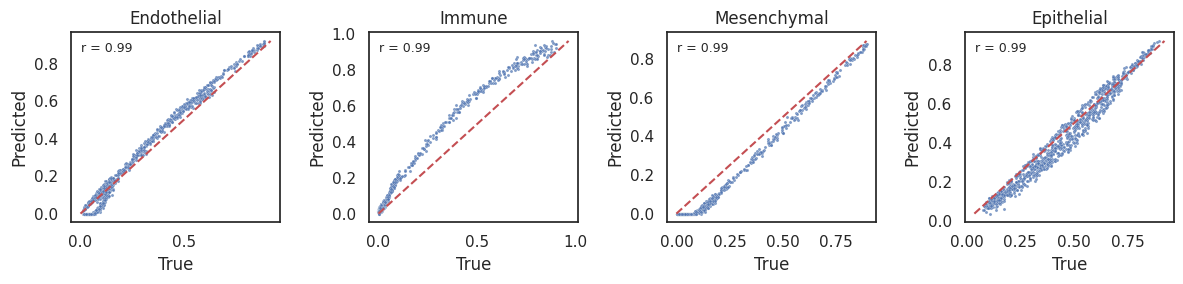

In [30]:
# Plot correlations (pearson)
plot_true_vs_predicted(test_czi_cell_prop[music_deconv.columns],music_deconv)

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Mean Absolute Error
mae = mean_absolute_error(test_czi_cell_prop[music_deconv.columns], music_deconv)

# Mean Squared Error
mse = mean_squared_error(test_czi_cell_prop[music_deconv.columns], music_deconv)

# Root Mean Squared Error
rmse = np.sqrt(mse)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE : 0.0447
MSE : 0.0033
RMSE: 0.0579


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Store results per column
results = []
for col in music_deconv.columns:
    y_true = test_czi_cell_prop[col]
    y_pred = music_deconv[col]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    results.append({"Cell_Type": col, "MAE": mae, "MSE": mse, "RMSE": rmse})

# Convert to DataFrame for easy plotting
results_df = pd.DataFrame(results)
print(results_df)

     Cell_Type       MAE       MSE      RMSE
0  Endothelial  0.038251  0.001906  0.043653
1       Immune  0.055560  0.006115  0.078196
2  Mesenchymal  0.046608  0.003194  0.056515
3   Epithelial  0.038213  0.002185  0.046739


### NNLS with Geneformer

In [102]:
# Read geneformer embeddings 
sig_matrix_gf = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/geneformer_signature_matrix_from_pseudobulk.csv", index_col=0)

# Reset and drop index
#sig_matrix_gf.reset_index(drop=True, inplace=True)

#Group by heca_lineage and average embeddings 
#sig_matrix_gf = sig_matrix_gf.groupby("heca_lineage").mean(numeric_only=True)
sig_matrix_gf = sig_matrix_gf.T

# Add gf to front of embeddings
sig_matrix_gf.index = ["gf_" + str(i) for i in sig_matrix_gf.index]

# Drop index name
sig_matrix_gf = sig_matrix_gf.rename_axis(None, axis=1)
sig_matrix_gf = sig_matrix_gf[["Endothelial", "Immune", "Mesenchymal", "Epithelial"]]

In [35]:
sig_matrix_gf.head()

,Endothelial,Immune,Mesenchymal,Epithelial
gf_0,-0.053017,-0.050654,-0.053539,-0.043215
gf_1,-0.087242,-0.089509,-0.088556,-0.082986
gf_2,0.006021,-0.003097,0.009340,0.014009
gf_3,0.040007,0.044844,0.039801,0.043031
gf_4,-0.007286,-0.014052,0.011241,0.000177


In [36]:
# Transpose pseudobulk to match signature matrix 
gf_latent_czi_pseudobulk_test_T = gf_latent_czi_pseudobulk_test.copy().T

# add "scVI" to index names
gf_latent_czi_pseudobulk_test_T.index = ["gf_" + str(i) for i in gf_latent_czi_pseudobulk_test_T.index]

In [37]:
nnls_gf = estimate_proportions(bulk_df = gf_latent_czi_pseudobulk_test_T, signature_matrix = sig_matrix_gf)

In [104]:
# Reset seaborn to matplotlib defaults
sns.set_theme(style="white")       # white background
sns.set_style("white", rc={"axes.grid": False})  # remove grid lines

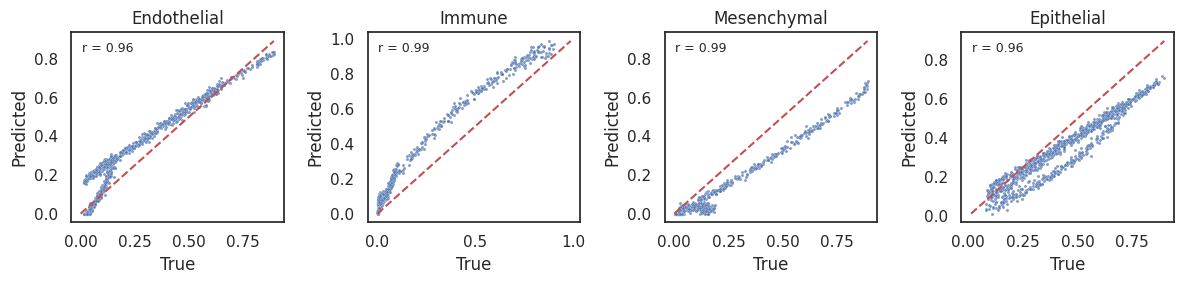

In [39]:
plot_true_vs_predicted(y_test_df=test_czi_cell_prop[nnls_gf.columns], predicted_proportions=nnls_gf)

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Mean Absolute Error
mae = mean_absolute_error(test_czi_cell_prop[nnls_gf.columns], nnls_gf)

# Mean Squared Error
mse = mean_squared_error(test_czi_cell_prop[nnls_gf.columns], nnls_gf)

# Root Mean Squared Error
rmse = np.sqrt(mse)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE : 0.0814
MSE : 0.0102
RMSE: 0.1012


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Store results per column
results = []
for col in nnls_gf.columns:
    y_true = test_czi_cell_prop[col]
    y_pred = nnls_gf[col]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    results.append({"Cell_Type": col, "MAE": mae, "MSE": mse, "RMSE": rmse})

# Convert to DataFrame for easy plotting
results_df = pd.DataFrame(results)
print(results_df)

     Cell_Type       MAE       MSE      RMSE
0  Endothelial  0.078544  0.008920  0.094446
1       Immune  0.085323  0.010275  0.101366
2  Mesenchymal  0.063527  0.008565  0.092546
3   Epithelial  0.098126  0.013199  0.114886


### NNLS Geneformer + Harmonypy

In [96]:
gf_harmony = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/geneformer_harmony_train_and_test.csv", index_col= 0)
gf_harmony = gf_harmony[gf_harmony.source == "test"]
gf_harmony_test = gf_harmony.iloc[:, :-2]

In [99]:
# Transpose pseudobulk to match signature matrix 
gf_harmony_test_T = gf_harmony_test.copy().T

# add "scVI" to index names
gf_harmony_test_T.index = ["gf_" + str(i) for i in gf_harmony_test_T.index]

In [103]:
nnls_gf_harmony = estimate_proportions(bulk_df = gf_harmony_test_T, signature_matrix = sig_matrix_gf)

In [108]:
nnls_gf_harmony.reset_index(drop=True, inplace=True)

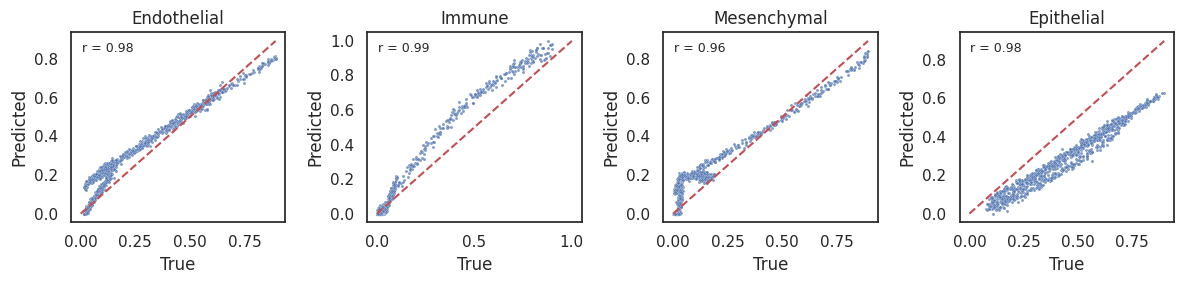

In [110]:
plot_true_vs_predicted(y_test_df=test_czi_cell_prop[nnls_gf_harmony.columns], predicted_proportions=nnls_gf_harmony)

In [111]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Mean Absolute Error
mae = mean_absolute_error(test_czi_cell_prop[nnls_gf_harmony.columns], nnls_gf_harmony)

# Mean Squared Error
mse = mean_squared_error(test_czi_cell_prop[nnls_gf_harmony.columns], nnls_gf_harmony)

# Root Mean Squared Error
rmse = np.sqrt(mse)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE : 0.0861
MSE : 0.0120
RMSE: 0.1097


In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Store results per column
results = []
for col in nnls_gf_harmony.columns:
    y_true = test_czi_cell_prop[col]
    y_pred = nnls_gf_harmony[col]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    results.append({"Cell_Type": col, "MAE": mae, "MSE": mse, "RMSE": rmse})

# Convert to DataFrame for easy plotting
results_df = pd.DataFrame(results)
print(results_df)

     Cell_Type       MAE       MSE      RMSE
0  Endothelial  0.067021  0.006370  0.079810
1       Immune  0.046391  0.005470  0.073959
2  Mesenchymal  0.077280  0.008696  0.093253
3   Epithelial  0.153575  0.027640  0.166253


### NNLS with PCA

In [53]:
test_pseudobulk_czi = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/pseudobulk_test_set.csv")

In [54]:
signature_matrix_by_gex = create_signature_matrix(adata_train, groupby = "heca_lineage")

In [55]:
signature_matrix_by_gex.shape

(36592, 4)

In [56]:
signature_matrix_by_gex.head()

heca_lineage,Endothelial,Epithelial,Immune,Mesenchymal
ENSG00000243485,0.000000,0.000000,0.000000,0.000000
ENSG00000237613,0.000000,0.000000,0.000000,0.000000
ENSG00000186092,0.000000,0.000461,0.000000,0.000210
ENSG00000238009,0.003576,0.008758,0.002045,0.003146
ENSG00000239945,0.000275,0.000000,0.002045,0.000000


In [57]:
test_pseudobulk_czi.head()

,ENSG00000243485,ENSG00000237613,ENSG00000186092,ENSG00000238009,ENSG00000239945,ENSG00000239906,ENSG00000241860,ENSG00000241599,ENSG00000286448,ENSG00000236601,...,ENSG00000274175,ENSG00000275869,ENSG00000273554,ENSG00000278782,ENSG00000277761,ENSG00000277836,ENSG00000278633,ENSG00000276017,ENSG00000278817,ENSG00000277196
0,0.0,0.0,1.0,9.0,0.0,0.0,11.0,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,6.0,0.0,0.0,11.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
2,0.0,0.0,0.0,4.0,0.0,0.0,21.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,1.0,0.0
3,0.0,0.0,0.0,31.0,0.0,0.0,9.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,8.0,0.0,0.0,8.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0


In [58]:
# Match 
signature_matrix_by_gex = signature_matrix_by_gex.loc[test_pseudobulk_czi.columns]

In [59]:
pd.Series(signature_matrix_by_gex.index == test_pseudobulk_czi.columns).value_counts()

True    36592
Name: count, dtype: int64

In [60]:
# concat on gene names
sig_matrix_bulk_concat = pd.concat([test_pseudobulk_czi, signature_matrix_by_gex.T], ignore_index=False)

In [61]:
sig_matrix_bulk_concat.shape

(1004, 36592)

In [62]:
sig_matrix_bulk_concat.tail()

,ENSG00000243485,ENSG00000237613,ENSG00000186092,ENSG00000238009,ENSG00000239945,ENSG00000239906,ENSG00000241860,ENSG00000241599,ENSG00000286448,ENSG00000236601,...,ENSG00000274175,ENSG00000275869,ENSG00000273554,ENSG00000278782,ENSG00000277761,ENSG00000277836,ENSG00000278633,ENSG00000276017,ENSG00000278817,ENSG00000277196
999,0.0,0.0,0.000000,19.000000,0.000000,0.0,20.000000,1.00000,0.00000,0.0,...,0.0,0.0,0.000000,0.00000,0.00000,0.0,0.000000,0.000000,0.000000,0.000000
Endothelial,0.0,0.0,0.000000,0.003576,0.000275,0.0,0.004677,0.00000,0.00000,0.0,...,0.0,0.0,0.000275,0.00000,0.00000,0.0,0.000275,0.000000,0.000825,0.000000
Epithelial,0.0,0.0,0.000461,0.008758,0.000000,0.0,0.030422,0.00507,0.00000,0.0,...,0.0,0.0,0.000000,0.00000,0.00000,0.0,0.000230,0.000230,0.000230,0.000000
Immune,0.0,0.0,0.000000,0.002045,0.002045,0.0,0.014315,0.00409,0.00000,0.0,...,0.0,0.0,0.000000,0.00000,0.00000,0.0,0.000000,0.002045,0.000000,0.000000
Mesenchymal,0.0,0.0,0.000210,0.003146,0.000000,0.0,0.005453,0.00000,0.00021,0.0,...,0.0,0.0,0.000839,0.00021,0.00021,0.0,0.000839,0.000839,0.001678,0.000839


In [63]:
# Standardize the data
scaler = StandardScaler()
sig_matrix_bulk_concat_scaled = scaler.fit_transform(sig_matrix_bulk_concat.copy())

# Run PCA
pca = PCA(n_components=100) 
pca_merged = pca.fit_transform(sig_matrix_bulk_concat)

In [64]:
# transform to dataframe
pca_merged = pd.DataFrame(pca_merged)

In [65]:
# add "PC" to index names
pca_merged.columns = ["PC_" + str(i) for i in range(0, pca_merged.shape[1])]

In [66]:
# Sig Matrix 
sig_mat_pca = pca_merged.iloc[-4:,:]
sig_mat_pca.index = sig_matrix_bulk_concat.iloc[-4:,:].index
sig_mat_pca = sig_mat_pca.T

In [67]:
sig_mat_pca.head()

,Endothelial,Epithelial,Immune,Mesenchymal
PC_0,-110066.261282,-110005.808898,-110053.626596,-110050.552477
PC_1,-12255.945247,-12169.057589,-12241.575722,-12245.264493
PC_2,-38245.814668,-38252.669455,-38283.264414,-38284.657644
PC_3,-54460.774159,-54445.691325,-54472.950583,-54425.677231
PC_4,1387.974708,1399.522291,1390.418363,1390.908052


In [68]:
# Pseuddovulk pca
test_pseudobulk_pca = pca_merged.iloc[0:1000, :]
test_pseudobulk_pca = test_pseudobulk_pca.T

In [69]:
test_pseudobulk_pca.head()

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
PC_0,-9004.064619,-19555.925389,-21898.571158,39336.904733,-11290.601896,-1679.752100,-4563.338085,52810.204580,-3397.290261,-16331.744882,...,-26611.989336,41306.227131,-9752.919875,-7762.100242,-15257.803222,12237.160739,-1607.522750,-3623.528682,-30541.147291,35478.828330
PC_1,-3688.239265,-26267.736378,-7299.270470,-3870.112658,-17397.617004,16173.836952,17838.189062,-19169.393362,9536.968978,-12522.378712,...,-10964.396127,-12873.399321,-10362.091470,-8381.543740,8204.725683,14483.596374,26118.916222,18668.831692,-15688.507957,1024.541377
PC_2,5979.783919,17568.201132,-16852.034819,-3528.797268,6686.924517,4170.356742,-1052.678246,-8102.998163,4216.888193,12821.086436,...,-19481.146902,-6591.477279,7790.457209,13006.068604,-9214.358877,1682.479192,1497.139164,2854.550404,-23028.318032,-1783.870040
PC_3,-1022.469889,-814.099785,6309.242526,-616.569755,-372.823524,171.446279,266.078511,-1555.723936,474.380470,-1652.954813,...,4815.252425,-465.235813,-167.728145,1445.544822,516.282934,747.082785,-1223.623229,-1249.068786,6697.804633,1170.020803
PC_4,335.917300,739.488620,-198.498917,323.170034,105.253789,-272.388047,-526.057943,-2043.748197,-49.090689,-160.093474,...,22.658463,-3807.924620,-70.352822,-632.311476,784.489488,-701.696370,-656.635624,-359.075052,299.006642,-280.556627


In [70]:
nnls_pca = estimate_proportions(bulk_df = test_pseudobulk_pca, signature_matrix = sig_mat_pca)

/tmp/ipykernel_211190/3817360047.py:28: RuntimeWarning: invalid value encountered in divide
  coeffs = coeffs / coeffs.sum()  # normalize to proportions
/tmp/ipykernel_211190/3817360047.py:28: RuntimeWarning: invalid value encountered in divide
  coeffs = coeffs / coeffs.sum()  # normalize to proportions
/tmp/ipykernel_211190/3817360047.py:28: RuntimeWarning: invalid value encountered in divide
  coeffs = coeffs / coeffs.sum()  # normalize to proportions
/tmp/ipykernel_211190/3817360047.py:28: RuntimeWarning: invalid value encountered in divide
  coeffs = coeffs / coeffs.sum()  # normalize to proportions
/tmp/ipykernel_211190/3817360047.py:28: RuntimeWarning: invalid value encountered in divide
  coeffs = coeffs / coeffs.sum()  # normalize to proportions
/tmp/ipykernel_211190/3817360047.py:28: RuntimeWarning: invalid value encountered in divide
  coeffs = coeffs / coeffs.sum()  # normalize to proportions
/tmp/ipykernel_211190/3817360047.py:28: RuntimeWarning: invalid value encountered 

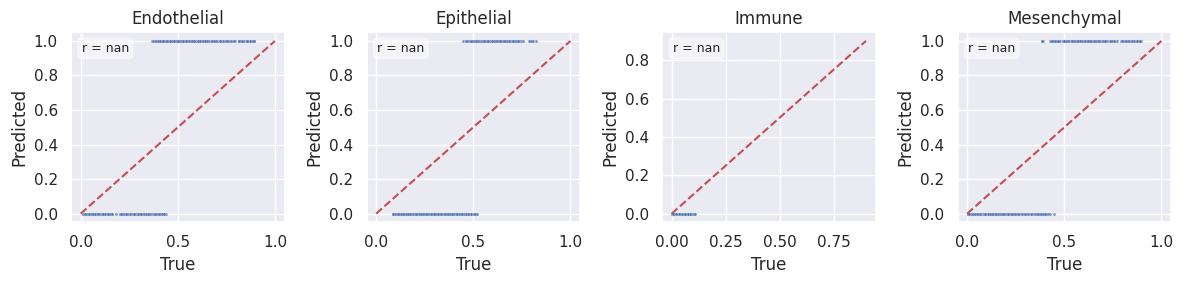

In [71]:
plot_true_vs_predicted(test_czi_cell_prop, nnls_pca)

In [52]:
nnls_pca

,Endothelial,Epithelial,Immune,Mesenchymal
0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0
3,NaN,NaN,NaN,NaN
4,1.0,0.0,0.0,0.0
...,...,...,...,...
995,NaN,NaN,NaN,NaN
996,NaN,NaN,NaN,NaN
997,0.0,1.0,0.0,0.0
998,0.0,0.0,0.0,1.0
